# Task 1: Predicting the Market Value of Young African Football Players

## Mission statement

My mission is to help young Africans discover their talents and develop
them in order to improve the level of sports on the African continent. I
also want to contribute to safe environments where young athletes can build
successful careers in their home continent rather than feeling that they
must move to Europe or America.

## Specific regression use case

This project develops a regression model that estimates the market value of
African football players aged 16–25 from their match participation,
performance, position, nationality, league, competition type, and season.

This is not a generic use case. It connects directly to the mission because
academies and sports-development organizations can use performance evidence
to understand which young athletes may benefit from further development,
scouting, or investment.

A predicted market value is not a complete measure of talent. It can be
influenced by league visibility, club reputation, nationality, and transfer
market conditions. The model should therefore support—not replace—human
scouting decisions.

## Dataset source

Kaggle: **Football Player Performance and Personal Data**  
https://www.kaggle.com/datasets/berkayyce/football-player-performance-and-personal-data

The supplied CSV has **4,834 rows and 38 columns**. It contains player-season
performance records from domestic leagues and international competitions.

## Four required algorithms

1. Batch Gradient Descent Linear Regression
2. Scikit-learn `SGDRegressor`
3. `DecisionTreeRegressor`
4. `RandomForestRegressor`

In [2]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display, Markdown

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y

import json
import re
import sys
from zipfile import ZipFile, ZIP_DEFLATED

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

RANDOM_STATE = 42
MINIMUM_AGE = 16
MAXIMUM_AGE = 25
TEST_SIZE = 0.20

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## Self-contained dataset and model utilities

In [ ]:
COLUMN_RENAME = {
    "Oyuncu": "player", "Yaş": "age", "Uyruk": "nationality",
    "Mevki": "position_code", "Sezon": "season", "Lig": "league",
    "Kategori": "competition_category", "MP": "matches_played",
    "DK": "minutes_played", "GLS": "goals", "AST": "assists",
    "ASR": "average_rating", "TOS": "total_shots",
    "SOT": "shots_on_target", "BCM": "big_chances_missed",
    "KEYP": "key_passes", "BCC": "big_chances_created",
    "SDR": "successful_dribbles", "APS": "accurate_passes",
    "APS%": "pass_accuracy_percent", "ALB": "accurate_long_balls",
    "LBA%": "long_ball_accuracy_percent", "ACR": "accurate_crosses",
    "CA%": "cross_accuracy_percent", "CLS": "clearances",
    "YC": "yellow_cards", "RC": "red_cards",
    "ELTG": "errors_leading_to_goal", "DRP": "dribbled_past",
    "TACK": "tackles", "INT": "interceptions",
    "BLS": "blocked_shots", "ADW": "aerial_duels_won",
    "xG": "expected_goals", "xA": "expected_assists",
    "GI": "goal_involvements", "XGI": "expected_goal_involvements",
    "Bonservis": "market_value_raw",
}

MARKET_VALUE_CORRECTIONS = {
    "400.00": "400.000", "30.000.00": "30.000.000",
    "28.000.00": "28.000.000", "1.000.00": "1.000.000",
    "20.000.00": "20.000.000", "1.500.00": "1.500.000",
    "12.000.0000": "12.000.000", "5.000.0000": "5.000.000",
    "30.000.0000": "30.000.000", "800.0000": "800.000",
}

AFRICAN_NATIONALITIES = {
    "ALG": "Algeria", "BUR": "Burkina Faso", "CIV": "Côte d'Ivoire",
    "CMR": "Cameroon", "COD": "DR Congo", "EGY": "Egypt",
    "GAM": "Gambia", "GBS": "Guinea-Bissau", "GHA": "Ghana",
    "MAR": "Morocco", "MLI": "Mali", "NGR": "Nigeria",
    "SEN": "Senegal", "ZAM": "Zambia", "ZIM": "Zimbabwe",
}

POSITION_LABELS = {"D": "Defender", "OS": "Midfielder", "F": "Forward"}

COUNT_COLUMNS = [
    "goals", "assists", "total_shots", "shots_on_target",
    "big_chances_missed", "key_passes", "big_chances_created",
    "successful_dribbles", "accurate_passes", "accurate_long_balls",
    "accurate_crosses", "clearances", "yellow_cards", "red_cards",
    "errors_leading_to_goal", "dribbled_past", "tackles",
    "interceptions", "blocked_shots", "aerial_duels_won",
]

RAW_MODEL_COLUMNS = [
    "age", "nationality", "position_code", "season", "league",
    "competition_category", "matches_played", "minutes_played", "goals",
    "assists", "average_rating", "total_shots", "shots_on_target",
    "big_chances_missed", "key_passes", "big_chances_created",
    "successful_dribbles", "accurate_passes", "pass_accuracy_percent",
    "accurate_long_balls", "long_ball_accuracy_percent", "accurate_crosses",
    "cross_accuracy_percent", "clearances", "yellow_cards", "red_cards",
    "errors_leading_to_goal", "dribbled_past", "tackles", "interceptions",
    "blocked_shots", "aerial_duels_won",
]

NUMERIC_FEATURES = [
    "age", "season_start_year", "matches_played", "minutes_played",
    "minutes_per_match", "average_rating", "pass_accuracy_percent",
    "long_ball_accuracy_percent", "cross_accuracy_percent",
    "goal_contributions_per90", "shot_accuracy", "goals_per_shot",
] + [f"{column}_per90" for column in COUNT_COLUMNS]

CATEGORICAL_FEATURES = [
    "nationality", "position", "league", "competition_category",
]


def season_start_year(value: object) -> int:
    text = str(value).strip()
    if "/" in text:
        first_part = int(text.split("/")[0])
        return 2000 + first_part if first_part < 50 else 1900 + first_part
    if re.fullmatch(r"\d{4}", text):
        return int(text)
    raise ValueError(f"Unsupported season format: {value!r}")


def clean_source_dataset(raw_data: pd.DataFrame) -> pd.DataFrame:
    missing = set(COLUMN_RENAME).difference(raw_data.columns)
    if missing:
        raise KeyError("Missing expected columns: " + ", ".join(sorted(missing)))

    data = raw_data.rename(columns=COLUMN_RENAME).copy()
    for column in data.select_dtypes(include="object").columns:
        data[column] = data[column].astype(str).str.strip()

    data["market_value_clean"] = data["market_value_raw"].replace(
        MARKET_VALUE_CORRECTIONS
    )
    valid = data["market_value_clean"].str.fullmatch(r"\d{1,3}(?:\.\d{3})*")
    if not valid.all():
        bad = data.loc[~valid, "market_value_clean"].drop_duplicates().to_list()
        raise ValueError(f"Unrecognized market-value formats: {bad}")

    data["market_value_eur"] = (
        data["market_value_clean"].str.replace(".", "", regex=False).astype("int64")
    )
    data["season_start_year"] = data["season"].map(season_start_year)
    data["position"] = data["position_code"].map(POSITION_LABELS)
    return data


def filter_mission_population(data, minimum_age=16, maximum_age=25):
    mission_data = data.loc[
        data["nationality"].isin(AFRICAN_NATIONALITIES)
        & data["age"].between(minimum_age, maximum_age, inclusive="both")
    ].copy()
    mission_data["nationality_name"] = mission_data["nationality"].map(
        AFRICAN_NATIONALITIES
    )
    mission_data["player_season_group"] = (
        mission_data["player"].astype(str) + "__" + mission_data["season"].astype(str)
    )
    return mission_data


def prepare_model_features(data: pd.DataFrame) -> pd.DataFrame:
    missing = set(RAW_MODEL_COLUMNS).difference(data.columns)
    if missing:
        raise KeyError("Missing required model columns: " + ", ".join(sorted(missing)))

    features = data.copy()
    features["season_start_year"] = features["season"].map(season_start_year)
    features["position"] = features["position_code"].map(POSITION_LABELS)
    minutes = pd.to_numeric(features["minutes_played"], errors="coerce").replace(0, np.nan)
    matches = pd.to_numeric(features["matches_played"], errors="coerce").replace(0, np.nan)

    for column in COUNT_COLUMNS:
        values = pd.to_numeric(features[column], errors="coerce")
        features[f"{column}_per90"] = values * 90.0 / minutes

    features["minutes_per_match"] = pd.to_numeric(
        features["minutes_played"], errors="coerce"
    ) / matches
    features["goal_contributions_per90"] = (
        pd.to_numeric(features["goals"], errors="coerce")
        + pd.to_numeric(features["assists"], errors="coerce")
    ) * 90.0 / minutes
    features["shot_accuracy"] = pd.to_numeric(
        features["shots_on_target"], errors="coerce"
    ) / pd.to_numeric(features["total_shots"], errors="coerce").replace(0, np.nan)
    features["goals_per_shot"] = pd.to_numeric(
        features["goals"], errors="coerce"
    ) / pd.to_numeric(features["total_shots"], errors="coerce").replace(0, np.nan)

    return features[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()


class BatchGradientDescentRegressor(RegressorMixin, BaseEstimator):
    def __init__(
        self, learning_rate=0.01, max_epochs=1200, l2_alpha=0.0001,
        tolerance=1e-8, n_iter_no_change=80,
    ):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.l2_alpha = l2_alpha
        self.tolerance = tolerance
        self.n_iter_no_change = n_iter_no_change

    def _initialize(self, X):
        self.coef_ = np.zeros(X.shape[1], dtype=float)
        self.intercept_ = 0.0
        self.train_loss_ = []
        self.validation_loss_ = []
        self.n_features_in_ = X.shape[1]

    def _gradient_step(self, X, y):
        predictions = X @ self.coef_ + self.intercept_
        errors = predictions - y
        n = X.shape[0]
        gradient_w = (2.0 / n) * (X.T @ errors) + 2.0 * self.l2_alpha * self.coef_
        gradient_b = 2.0 * float(np.mean(errors))
        gradient_w = np.clip(gradient_w, -1000.0, 1000.0)
        gradient_b = float(np.clip(gradient_b, -1000.0, 1000.0))
        self.coef_ -= self.learning_rate * gradient_w
        self.intercept_ -= self.learning_rate * gradient_b
        updated = X @ self.coef_ + self.intercept_
        return float(np.mean((updated - y) ** 2))

    def fit(self, X, y):
        X, y = check_X_y(X, y, accept_sparse=False, y_numeric=True)
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self._initialize(X)
        best_loss = np.inf
        no_change = 0
        for _ in range(self.max_epochs):
            loss = self._gradient_step(X, y)
            self.train_loss_.append(loss)
            if best_loss - loss > self.tolerance:
                best_loss = loss
                no_change = 0
            else:
                no_change += 1
            if no_change >= self.n_iter_no_change:
                break
        self.n_iter_ = len(self.train_loss_)
        return self

    def fit_with_validation(self, X, y, X_validation, y_validation):
        X, y = check_X_y(X, y, accept_sparse=False, y_numeric=True)
        X_validation = check_array(X_validation, accept_sparse=False)
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        X_validation = np.asarray(X_validation, dtype=float)
        y_validation = np.asarray(y_validation, dtype=float)
        self._initialize(X)
        best_loss = np.inf
        no_change = 0
        for _ in range(self.max_epochs):
            train_loss = self._gradient_step(X, y)
            validation_prediction = X_validation @ self.coef_ + self.intercept_
            validation_loss = float(np.mean((validation_prediction - y_validation) ** 2))
            self.train_loss_.append(train_loss)
            self.validation_loss_.append(validation_loss)
            if best_loss - validation_loss > self.tolerance:
                best_loss = validation_loss
                no_change = 0
            else:
                no_change += 1
            if no_change >= self.n_iter_no_change:
                break
        self.n_iter_ = len(self.train_loss_)
        return self

    def predict(self, X):
        check_is_fitted(self, ["coef_", "intercept_"])
        X = check_array(X, accept_sparse=False)
        return np.asarray(X, dtype=float) @ self.coef_ + self.intercept_

In [4]:
IN_COLAB = "google.colab" in sys.modules
WORK_DIR = Path("/content/african_football_task1") if IN_COLAB else Path.cwd() / "african_football_task1"
PROCESSED_DIR = WORK_DIR / "data" / "processed"
MODEL_DIR = WORK_DIR / "models"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

environment_versions = pd.DataFrame(
    {
        "package": ["Python", "pandas", "NumPy", "scikit-learn", "joblib"],
        "version": [
            sys.version.split()[0], pd.__version__, np.__version__,
            sklearn.__version__, joblib.__version__,
        ],
    }
)
display(environment_versions)
WORK_DIR

,package,version
0,Python,3.12.13
1,pandas,2.2.2
2,NumPy,2.0.2
3,scikit-learn,1.6.1
4,joblib,1.5.3


PosixPath('/content/african_football_task1')

## Step 1 — Load and inspect the supplied dataset

In [1]:
from pathlib import Path
import pandas as pd


def locate_dataset() -> Path:
    """Locate dataset.csv in Colab or in the GitHub project."""

    possible_paths = [
        # Google Colab
        Path("/content/dataset.csv"),

        # Notebook and current-folder options
        Path.cwd() / "dataset.csv",
        Path.cwd() / "linear_regression" / "dataset.csv",
        Path.cwd() / "summative" / "linear_regression" / "dataset.csv",
    ]

    # Search parent directories for the repository structure
    for parent in [Path.cwd(), *Path.cwd().parents]:
        possible_paths.extend(
            [
                parent / "dataset.csv",
                parent / "linear_regression" / "dataset.csv",
                parent / "summative" / "linear_regression" / "dataset.csv",
            ]
        )

    for path in possible_paths:
        if path.exists():
            return path.resolve()

    raise FileNotFoundError(
        "dataset.csv was not found. Place it inside "
        "summative/linear_regression/ or upload it to Colab."
    )


DATA_PATH = locate_dataset()
raw_df = pd.read_csv(DATA_PATH)

DATA_PATH

WindowsPath('C:/Users/YES TECHNOLOGY/Downloads/linear_regression_model/summative/linear_regression/dataset.csv')

In [6]:
dataset_overview = pd.DataFrame(
    {
        "measurement": [
            "rows",
            "columns",
            "exact duplicate rows",
            "unique players",
            "unique nationalities",
            "unique leagues",
        ],
        "value": [
            raw_df.shape[0],
            raw_df.shape[1],
            raw_df.duplicated().sum(),
            raw_df["Oyuncu"].nunique(),
            raw_df["Uyruk"].nunique(),
            raw_df["Lig"].nunique(),
        ],
    }
)

dataset_overview

,measurement,value
0,rows,4834
1,columns,38
2,exact duplicate rows,0
3,unique players,464
4,unique nationalities,57
5,unique leagues,69


In [7]:
source_column_dictionary = pd.DataFrame(
    {
        "original_column": raw_df.columns,
        "meaning_used_in_project": [
            "Player",
            "Age",
            "Nationality code",
            "Position code",
            "Season",
            "League or competition",
            "Competition category",
            "Matches played",
            "Minutes played",
            "Goals",
            "Assists",
            "Average rating",
            "Total shots",
            "Shots on target",
            "Big chances missed",
            "Key passes",
            "Big chances created",
            "Successful dribbles",
            "Accurate passes",
            "Pass accuracy percentage",
            "Accurate long balls",
            "Long-ball accuracy percentage",
            "Accurate crosses",
            "Cross accuracy percentage",
            "Clearances",
            "Yellow cards",
            "Red cards",
            "Errors leading to a goal",
            "Times dribbled past",
            "Tackles",
            "Interceptions",
            "Blocked shots",
            "Aerial duels won",
            "Expected goals",
            "Expected assists",
            "Goal involvements",
            "Expected goal involvements",
            "Market value in euros",
        ],
    }
)

source_column_dictionary

,original_column,meaning_used_in_project
0,Oyuncu,Player
1,Yaş,Age
2,Uyruk,Nationality code
3,Mevki,Position code
4,Sezon,Season
5,Lig,League or competition
6,Kategori,Competition category
7,MP,Matches played
8,DK,Minutes played
9,GLS,Goals


In [8]:
missing_before_cleaning = (
    raw_df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_percentage=lambda table:
        table["missing_count"] / len(raw_df) * 100
    )
    .sort_values("missing_percentage", ascending=False)
)

missing_before_cleaning.head(15)

,missing_count,missing_percentage
xG,3070,63.508
xA,2982,61.688
XGI,2981,61.667
CA%,1689,34.940
ACR,744,15.391
ADW,496,10.261
BLS,457,9.454
SOT,457,9.454
TOS,457,9.454
LBA%,412,8.523


**Initial interpretation**

The dataset is rich in both volume and variety: it has player identity,
season, league, position, minutes, attacking statistics, passing
statistics, defensive statistics, expected-goal measures, and a continuous
market-value target. This makes it suitable for regression.

The same player and season may appear in both a domestic league and an
international competition. That structure must be respected when splitting
the data so the same player-season target does not appear in both training
and testing sets.

## Step 2 — Clean the Turkish columns and market-value target

In [9]:
raw_market_values = raw_df["Bonservis"].astype(str).str.strip()

malformed_market_values = (
    raw_df.loc[
        ~raw_market_values.str.fullmatch(
            r"\d{1,3}(?:\.\d{3})*"
        ),
        ["Oyuncu", "Yaş", "Sezon", "Lig", "Bonservis"],
    ]
    .copy()
)

malformed_market_values

,Oyuncu,Yaş,Sezon,Lig,Bonservis
635,Calvin Bassey,21,20/21,Scottish Premiership,400.00
3573,Nicolas Jackson,21,22/23,LaLiga,30.000.00
3590,Noni Madueke,20,22/23,Premier League,28.000.00
3697,Omari Kellyman,18,23/24,UEFA Conference League,1.000.00
4279,Sergio Reguilon,27,23/24,UEFA Champions League,12.000.0000
4493,Tyler Adams,22,21/22,Bundesliga,20.000.00
4500,Tyler Adams,22,21/22,UEFA Europa League,20.000.00
4501,Tyler Adams,22,21/22,UEFA Champions League,20.000.00
4528,Tyrone Mings,25,18/19,Championship,5.000.0000
4567,Virgil Van Dijk,25,16/17,Premier League,30.000.0000


In [10]:
data = clean_source_dataset(raw_df)

market_value_audit = pd.DataFrame(
    {
        "raw_value": raw_df["Bonservis"].astype(str).str.strip(),
        "clean_value_eur": data["market_value_eur"],
    }
)

display(market_value_audit.loc[malformed_market_values.index])
data.head()

,raw_value,clean_value_eur
635,400.00,400000
3573,30.000.00,30000000
3590,28.000.00,28000000
3697,1.000.00,1000000
4279,12.000.0000,12000000
4493,20.000.00,20000000
4500,20.000.00,20000000
4501,20.000.00,20000000
4528,5.000.0000,5000000
4567,30.000.0000,30000000


,player,age,nationality,position_code,season,league,competition_category,matches_played,minutes_played,goals,assists,average_rating,total_shots,shots_on_target,big_chances_missed,key_passes,big_chances_created,successful_dribbles,accurate_passes,pass_accuracy_percent,accurate_long_balls,long_ball_accuracy_percent,accurate_crosses,cross_accuracy_percent,clearances,yellow_cards,red_cards,errors_leading_to_goal,dribbled_past,tackles,interceptions,blocked_shots,aerial_duels_won,expected_goals,expected_assists,goal_involvements,expected_goal_involvements,market_value_raw,market_value_clean,market_value_eur,season_start_year,position
0,Aaron Cresswell,35,ENG,D,24/25,Premier League,Domestic leagues,18,847,0,0,6.910,5.000,0.000,0,9,2,1,451.000,86.600,43.000,53.800,10.000,27.800,3,3,0,0,2,11,8,1.000,7.000,0.230,1.900,0.000,2.140,500.000,500.000,500000,2024,Defender
1,Aaron Cresswell,34,ENG,D,23/24,Premier League,Domestic leagues,11,453,0,0,6.580,NaN,NaN,0,5,1,0,206.000,83.400,14.000,41.200,4.000,36.400,0,1,0,0,1,3,3,NaN,6.000,NaN,0.340,0.000,0.340,900.000,900.000,900000,2023,Defender
2,Aaron Cresswell,33,ENG,D,22/23,Premier League,Domestic leagues,28,2241,0,1,6.880,9.000,1.000,0,40,4,2,912.000,81.500,64.000,50.400,42.000,31.600,5,3,0,0,19,21,27,6.000,28.000,0.350,2.850,1.000,3.200,1.200.000,1.200.000,1200000,2022,Defender
3,Aaron Cresswell,32,ENG,D,21/22,Premier League,Domestic leagues,31,2728,2,3,7.010,18.000,4.000,0,31,5,8,"1,412.000",82.600,81.000,38.600,34.000,23.400,7,3,0,0,12,28,35,7.000,32.000,NaN,NaN,5.000,NaN,2.500.000,2.500.000,2500000,2021,Defender
4,Aaron Cresswell,31,ENG,D,20/21,Premier League,Domestic leagues,36,3172,0,8,7.100,19.000,4.000,0,60,12,4,"1,303.000",78.900,119.000,41.600,59.000,28.500,11,3,0,0,14,32,32,3.000,35.000,NaN,NaN,8.000,NaN,5.000.000,5.000.000,5000000,2020,Defender


**Target conversion interpretation**

`Bonservis` uses periods as thousands separators, for example
`25.000.000` means €25,000,000. Ten malformed text patterns were corrected
using repeated records for the same player, age, and season. After those
corrections, the periods were removed and the target was converted to an
integer euro amount.

The original text target is not supplied to the model.

## Step 3 — Filter the mission population

In [11]:
mission_df = filter_mission_population(
    data,
    minimum_age=MINIMUM_AGE,
    maximum_age=MAXIMUM_AGE,
)

mission_summary = pd.DataFrame(
    {
        "measurement": [
            "all dataset rows",
            "young African rows",
            "unique young African players",
            "unique player-season groups",
            "African nationality codes represented",
            "minimum age",
            "maximum age",
        ],
        "value": [
            len(data),
            len(mission_df),
            mission_df["player"].nunique(),
            mission_df["player_season_group"].nunique(),
            mission_df["nationality"].nunique(),
            mission_df["age"].min(),
            mission_df["age"].max(),
        ],
    }
)

display(mission_summary)

nationality_summary = (
    mission_df.groupby(
        ["nationality", "nationality_name"],
        as_index=False,
    )
    .agg(
        rows=("player", "size"),
        players=("player", "nunique"),
    )
    .sort_values("rows", ascending=False)
)

nationality_summary

,measurement,value
0,all dataset rows,4834
1,young African rows,352
2,unique young African players,46
3,unique player-season groups,229
4,African nationality codes represented,15
5,minimum age,17
6,maximum age,25


,nationality,nationality_name,rows,players
8,GHA,Ghana,58,7
2,CIV,Côte d'Ivoire,51,7
11,NGR,Nigeria,49,6
10,MLI,Mali,32,5
12,SEN,Senegal,31,4
9,MAR,Morocco,23,3
5,EGY,Egypt,19,3
4,COD,DR Congo,19,2
13,ZAM,Zambia,18,1
1,BUR,Burkina Faso,14,2


**Mission-filter interpretation**

The supplied dataset contains 15 African nationality codes. After filtering
ages 16–25, the modelling sample contains 352 rows from 46 players and 229
player-season groups.

This is sufficient for a class project, but it is not fully representative
of every African country. For example, the dataset has no Rwandan players.
Results should therefore be described as a proof of concept rather than a
continent-wide valuation system.

## Step 4 — Visualize and interpret the data

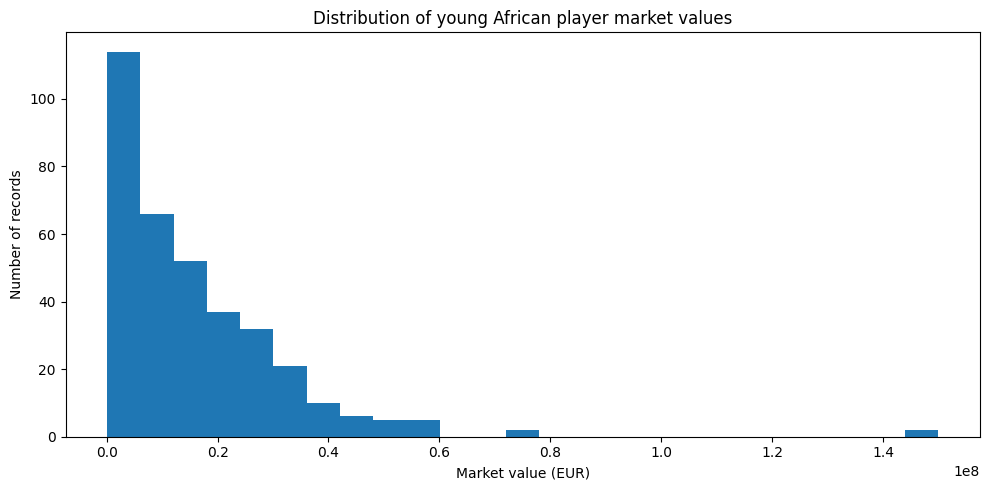

**Interpretation:** The target skewness is **3.21**. The distribution has a long right tail because a few players have much larger market values. The models will therefore learn `log1p(market_value_eur)` and convert predictions back to euros.

In [12]:
target_skewness = mission_df["market_value_eur"].skew()

plt.figure(figsize=(10, 5))
plt.hist(mission_df["market_value_eur"], bins=25)
plt.xlabel("Market value (EUR)")
plt.ylabel("Number of records")
plt.title("Distribution of young African player market values")
plt.tight_layout()
plt.show()

display(
    Markdown(
        f"**Interpretation:** The target skewness is "
        f"**{target_skewness:,.2f}**. The distribution has a long right "
        "tail because a few players have much larger market values. "
        "The models will therefore learn `log1p(market_value_eur)` and "
        "convert predictions back to euros."
    )
)

,position,records,median_market_value_eur,mean_market_value_eur
2,Midfielder,179,"15,000,000.000","19,572,905.028"
1,Forward,97,"12,000,000.000","15,674,226.804"
0,Defender,76,"7,000,000.000","8,502,631.579"


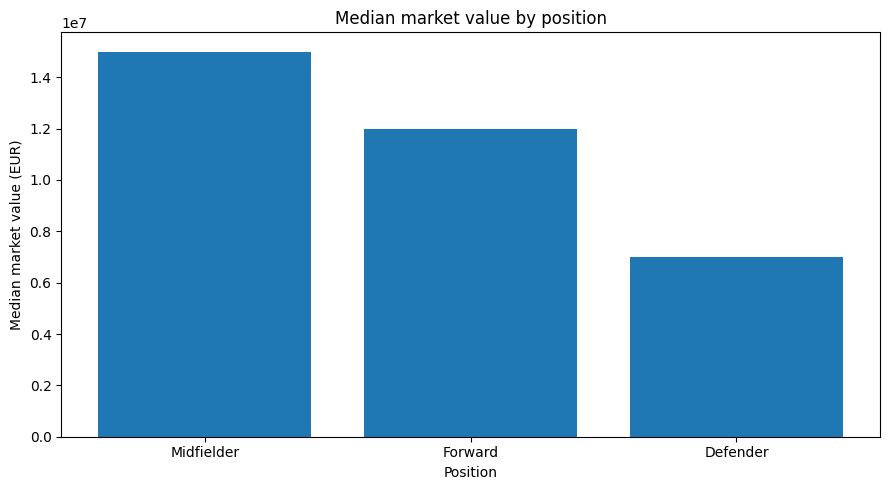

**Interpretation:** Position is associated with different median values in this sample, so position should be retained as a categorical predictor rather than converted into an artificial numeric ranking.

In [13]:
position_value_summary = (
    mission_df.groupby("position", as_index=False)
    .agg(
        records=("player", "size"),
        median_market_value_eur=("market_value_eur", "median"),
        mean_market_value_eur=("market_value_eur", "mean"),
    )
    .sort_values("median_market_value_eur", ascending=False)
)

display(position_value_summary)

plt.figure(figsize=(9, 5))
positions = position_value_summary["position"]
medians = position_value_summary["median_market_value_eur"]
plt.bar(positions, medians)
plt.xlabel("Position")
plt.ylabel("Median market value (EUR)")
plt.title("Median market value by position")
plt.tight_layout()
plt.show()

display(
    Markdown(
        "**Interpretation:** Position is associated with different median "
        "values in this sample, so position should be retained as a "
        "categorical predictor rather than converted into an artificial "
        "numeric ranking."
    )
)

,correlation_with_log_market_value
age,0.407
expected_goal_involvements,0.359
expected_goals,0.345
season_start_year,0.302
key_passes,0.280
expected_assists,0.277
average_rating,0.275
accurate_crosses,0.258
big_chances_created,0.249
goal_involvements,0.242


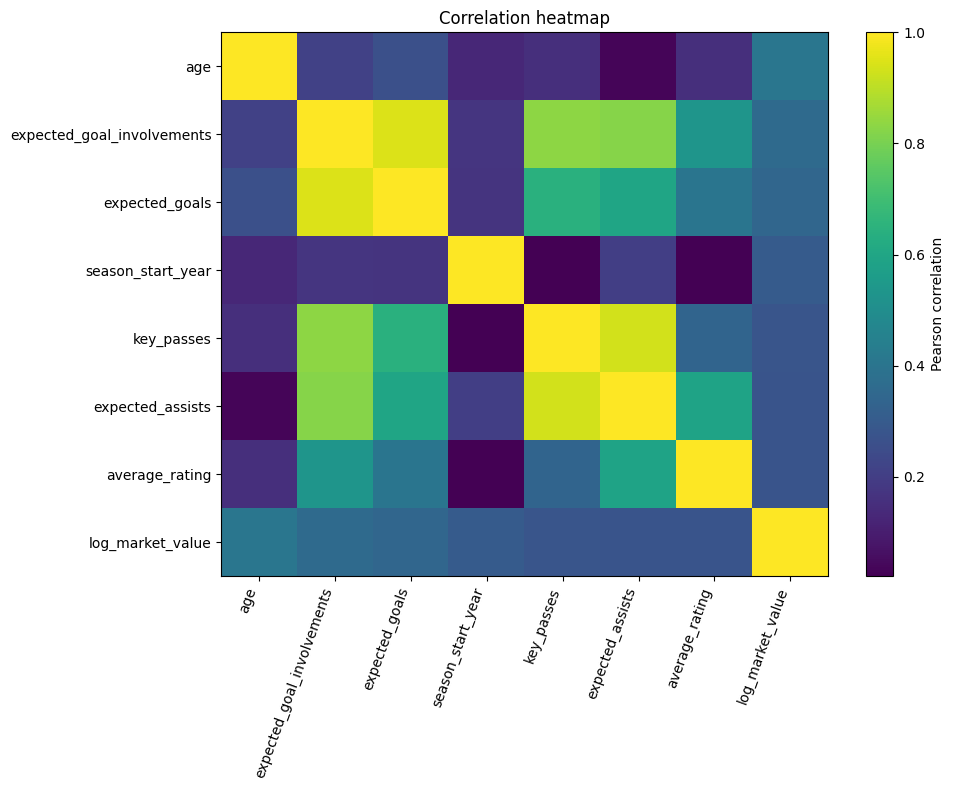

**Interpretation:** `age` has the strongest numeric linear relationship with log market value in the filtered sample (**r = 0.407**). Correlation does not prove causation.

In [14]:
numeric_for_correlation = mission_df.select_dtypes(
    include=np.number
).copy()
numeric_for_correlation["log_market_value"] = np.log1p(
    mission_df["market_value_eur"]
)

correlation_with_target = (
    numeric_for_correlation.corr(numeric_only=True)["log_market_value"]
    .drop(labels=["log_market_value", "market_value_eur"], errors="ignore")
    .dropna()
    .sort_values(key=np.abs, ascending=False)
)

top_correlations = correlation_with_target.head(10)
display(top_correlations.to_frame("correlation_with_log_market_value"))

heatmap_columns = top_correlations.head(7).index.to_list()
heatmap_frame = numeric_for_correlation[
    heatmap_columns + ["log_market_value"]
].corr()

figure, axis = plt.subplots(figsize=(10, 8))
image = axis.imshow(heatmap_frame.values, aspect="auto")
axis.set_xticks(range(len(heatmap_frame.columns)))
axis.set_xticklabels(
    heatmap_frame.columns,
    rotation=70,
    ha="right",
)
axis.set_yticks(range(len(heatmap_frame.index)))
axis.set_yticklabels(heatmap_frame.index)
axis.set_title("Correlation heatmap")
figure.colorbar(image, ax=axis, label="Pearson correlation")
figure.tight_layout()
plt.show()

display(
    Markdown(
        f"**Interpretation:** `{top_correlations.index[0]}` has the "
        f"strongest numeric linear relationship with log market value "
        f"in the filtered sample "
        f"(**r = {top_correlations.iloc[0]:,.3f}**). Correlation does "
        "not prove causation."
    )
)

## Step 5 — Feature engineering and feature selection

In [15]:
mission_missing = (
    mission_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_percentage")
)

mission_missing.head(12)

,missing_percentage
expected_goals,70.170
expected_assists,69.034
expected_goal_involvements,69.034
cross_accuracy_percent,42.898
accurate_crosses,19.602
long_ball_accuracy_percent,11.648
aerial_duels_won,10.511
total_shots,8.523
blocked_shots,8.523
shots_on_target,8.523


In [16]:
redundant_goal_involvement_rows = (
    mission_df["goal_involvements"]
    == mission_df["goals"] + mission_df["assists"]
).mean() * 100

feature_decisions = pd.DataFrame(
    {
        "column_or_group": [
            "player",
            "market_value_raw and market_value_clean",
            "expected_goals, expected_assists, expected_goal_involvements",
            "goal_involvements",
            "season",
            "position_code",
            "count statistics",
            "percentage and rating variables",
            "nationality, position, league, competition category",
        ],
        "decision": [
            "Drop from predictors; use only for grouping",
            "Drop because they contain the target",
            "Drop because approximately 69–70% is missing",
            "Drop because it equals goals + assists",
            "Convert to numeric season_start_year",
            "Convert D/OS/F to Defender/Midfielder/Forward",
            "Create per-90-minute rates",
            "Retain and median-impute where needed",
            "One-hot encode",
        ],
        "reason": [
            "Player identity would encourage memorization",
            "Direct target leakage",
            "Heavy imputation would be unreliable",
            f"Exact redundancy in {redundant_goal_involvement_rows:.1f}% of rows",
            "Captures time trend without treating text as a category",
            "Creates understandable category labels",
            "Makes players with different minutes more comparable",
            "They describe performance quality or efficiency",
            "Categories have no natural numeric order",
        ],
    }
)

feature_decisions

,column_or_group,decision,reason
0,player,Drop from predictors; use only for grouping,Player identity would encourage memorization
1,market_value_raw and market_value_clean,Drop because they contain the target,Direct target leakage
2,"expected_goals, expected_assists, expected_goa...",Drop because approximately 69–70% is missing,Heavy imputation would be unreliable
3,goal_involvements,Drop because it equals goals + assists,Exact redundancy in 100.0% of rows
4,season,Convert to numeric season_start_year,Captures time trend without treating text as a...
5,position_code,Convert D/OS/F to Defender/Midfielder/Forward,Creates understandable category labels
6,count statistics,Create per-90-minute rates,Makes players with different minutes more comp...
7,percentage and rating variables,Retain and median-impute where needed,They describe performance quality or efficiency
8,"nationality, position, league, competition cat...",One-hot encode,Categories have no natural numeric order


In [17]:
model_features = prepare_model_features(mission_df)

feature_type_summary = pd.DataFrame(
    {
        "feature_type": ["numeric", "categorical"],
        "count": [
            len(NUMERIC_FEATURES),
            len(CATEGORICAL_FEATURES),
        ],
        "features": [
            ", ".join(NUMERIC_FEATURES),
            ", ".join(CATEGORICAL_FEATURES),
        ],
    }
)

display(feature_type_summary)
model_features.head()

,feature_type,count,features
0,numeric,32,"age, season_start_year, matches_played, minute..."
1,categorical,4,"nationality, position, league, competition_cat..."


,age,season_start_year,matches_played,minutes_played,minutes_per_match,average_rating,pass_accuracy_percent,long_ball_accuracy_percent,cross_accuracy_percent,goal_contributions_per90,shot_accuracy,goals_per_shot,goals_per90,assists_per90,total_shots_per90,shots_on_target_per90,big_chances_missed_per90,key_passes_per90,big_chances_created_per90,successful_dribbles_per90,accurate_passes_per90,accurate_long_balls_per90,accurate_crosses_per90,clearances_per90,yellow_cards_per90,red_cards_per90,errors_leading_to_goal_per90,dribbled_past_per90,tackles_per90,interceptions_per90,blocked_shots_per90,aerial_duels_won_per90,nationality,position,league,competition_category
35,25,2018,35,3062,87.486,6.810,83.400,54.100,18.200,0.323,0.327,0.096,0.147,0.176,1.528,0.500,0.147,1.117,0.235,0.941,47.587,1.734,0.059,0.147,0.206,0.000,0.029,1.176,2.087,0.999,0.558,1.205,MLI,Midfielder,Premier League,Domestic leagues
36,24,2017,37,3325,89.865,7.020,83.600,59.200,23.100,0.271,0.362,0.149,0.189,0.081,1.272,0.460,0.027,1.083,0.027,1.110,50.806,2.274,0.162,0.244,0.271,0.000,0.000,1.408,2.138,1.462,0.271,1.164,MLI,Midfielder,Premier League,Domestic leagues
37,23,2016,20,1359,67.950,6.760,87.000,54.500,20.000,0.066,0.364,0.045,0.066,0.000,1.457,0.530,0.066,0.795,0.000,0.927,48.013,1.589,0.066,0.265,0.265,0.000,0.000,1.457,1.126,1.391,0.464,0.927,MLI,Midfielder,Premier League,Domestic leagues
38,22,2015,15,1156,77.067,6.810,83.900,69.800,NaN,0.156,0.000,0.000,0.000,0.156,0.779,0.000,0.078,0.856,0.078,0.467,36.436,2.881,0.000,0.234,0.389,0.000,0.000,0.623,2.413,2.413,0.389,1.090,MLI,Midfielder,LaLiga,Domestic leagues
39,22,2015,16,944,59.000,6.930,86.400,47.800,20.000,0.381,0.400,0.100,0.191,0.191,1.907,0.763,0.191,2.002,0.191,1.049,46.621,1.049,0.095,0.191,0.095,0.000,0.000,1.144,1.907,1.335,0.286,0.953,MLI,Midfielder,Ligue 1,Domestic leagues


The engineered features include minutes per match, goals and assists per 90
minutes, shooting efficiency, passing percentages, and defensive actions
per 90 minutes. Per-90 features reduce the unfair advantage of players who
simply accumulated more minutes.

The raw counts are not used together with every corresponding per-90 rate
because that would create unnecessary multicollinearity for the two linear
models. Matches and minutes are retained to preserve information about
availability and playing time.

## Step 6 — Grouped train/test split to prevent leakage

In [18]:
X = model_features
y = mission_df["market_value_eur"].copy()
groups = mission_df["player_season_group"].copy()

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_indices, test_indices = next(
    group_split.split(X, y, groups=groups)
)

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()
y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()
groups_train = groups.iloc[train_indices].copy()
groups_test = groups.iloc[test_indices].copy()

split_summary = pd.DataFrame(
    {
        "split": ["training", "testing"],
        "rows": [len(X_train), len(X_test)],
        "player-season groups": [
            groups_train.nunique(),
            groups_test.nunique(),
        ],
    }
)

display(split_summary)

overlap = set(groups_train).intersection(set(groups_test))
assert not overlap, "A player-season group appeared in both splits."

display(
    Markdown(
        "**Interpretation:** Rows from the same player and season are "
        "kept together. This prevents a player's domestic-league row from "
        "appearing in training while the same season's international "
        "competition row—with the same market value—appears in testing."
    )
)

,split,rows,player-season groups
0,training,276,183
1,testing,76,46


**Interpretation:** Rows from the same player and season are kept together. This prevents a player's domestic-league row from appearing in training while the same season's international competition row—with the same market value—appears in testing.

## Step 7 — Convert categories to numeric and standardize

In [19]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2,
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

preprocessing_summary = pd.DataFrame(
    {
        "data_type": ["numeric", "categorical"],
        "missing_value_method": [
            "Median imputation",
            "Most-frequent imputation",
        ],
        "conversion": [
            "StandardScaler",
            "OneHotEncoder",
        ],
    }
)

preprocessing_summary

,data_type,missing_value_method,conversion
0,numeric,Median imputation,StandardScaler
1,categorical,Most-frequent imputation,OneHotEncoder


Standardization is fitted only on the training data inside each pipeline.
This prevents information from the test set from influencing the means and
standard deviations used during training.

## Step 8 — Optimize Batch Gradient Descent

In [20]:
inner_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=7,
)

inner_train_indices, validation_indices = next(
    inner_split.split(
        X_train,
        y_train,
        groups=groups_train,
    )
)

X_inner_train = X_train.iloc[inner_train_indices]
X_validation = X_train.iloc[validation_indices]
y_inner_train = y_train.iloc[inner_train_indices]
y_validation = y_train.iloc[validation_indices]

batch_preprocessor = clone(preprocessor)
X_inner_processed = batch_preprocessor.fit_transform(X_inner_train)
X_validation_processed = batch_preprocessor.transform(X_validation)

y_inner_log = np.log1p(y_inner_train.to_numpy())
y_validation_log = np.log1p(y_validation.to_numpy())

batch_tuning_rows = []

for learning_rate in [0.001, 0.003, 0.01]:
    for l2_alpha in [0.0, 0.0001]:
        candidate = BatchGradientDescentRegressor(
            learning_rate=learning_rate,
            max_epochs=800,
            l2_alpha=l2_alpha,
            n_iter_no_change=80,
        )
        candidate.fit(
            X_inner_processed,
            y_inner_log,
        )
        validation_predictions = candidate.predict(
            X_validation_processed
        )
        validation_rmse = np.sqrt(
            mean_squared_error(
                y_validation_log,
                validation_predictions,
            )
        )

        batch_tuning_rows.append(
            {
                "learning_rate": learning_rate,
                "l2_alpha": l2_alpha,
                "validation_RMSE_log": validation_rmse,
                "epochs": candidate.n_iter_,
            }
        )

batch_tuning_results = (
    pd.DataFrame(batch_tuning_rows)
    .sort_values("validation_RMSE_log")
    .reset_index(drop=True)
)

display(batch_tuning_results)

BEST_BATCH_RATE = float(
    batch_tuning_results.iloc[0]["learning_rate"]
)
BEST_BATCH_ALPHA = float(
    batch_tuning_results.iloc[0]["l2_alpha"]
)

,learning_rate,l2_alpha,validation_RMSE_log,epochs
0,0.010,0.000,1.232,800
1,0.010,0.000,1.232,800
2,0.003,0.000,1.409,800
3,0.003,0.000,1.409,800
4,0.001,0.000,1.844,800
5,0.001,0.000,1.844,800


## Step 9 — Train and optimize all four required models

In [21]:
def model_with_log_target(regressor):
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", regressor),
        ]
    )

    return TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


batch_model = model_with_log_target(
    BatchGradientDescentRegressor(
        learning_rate=BEST_BATCH_RATE,
        max_epochs=1200,
        l2_alpha=BEST_BATCH_ALPHA,
        n_iter_no_change=100,
    )
)
batch_model.fit(X_train, y_train)

grouped_cv = GroupKFold(n_splits=3)

sgd_search = GridSearchCV(
    estimator=model_with_log_target(
        SGDRegressor(
            loss="squared_error",
            penalty="l2",
            learning_rate="adaptive",
            max_iter=10000,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=25,
            tol=1e-3,
            random_state=RANDOM_STATE,
        )
    ),
    param_grid={
        "regressor__model__eta0": [0.0001, 0.001],
        "regressor__model__alpha": [0.0001, 0.001],
    },
    scoring="neg_root_mean_squared_error",
    cv=grouped_cv,
    n_jobs=1,
)
sgd_search.fit(
    X_train,
    y_train,
    groups=groups_train,
)

tree_search = GridSearchCV(
    estimator=model_with_log_target(
        DecisionTreeRegressor(
            random_state=RANDOM_STATE,
        )
    ),
    param_grid={
        "regressor__model__max_depth": [6, None],
        "regressor__model__min_samples_leaf": [2, 5],
    },
    scoring="neg_root_mean_squared_error",
    cv=grouped_cv,
    n_jobs=1,
)
tree_search.fit(
    X_train,
    y_train,
    groups=groups_train,
)

forest_search = GridSearchCV(
    estimator=model_with_log_target(
        RandomForestRegressor(
            n_estimators=120,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),
    param_grid={
        "regressor__model__max_depth": [10, None],
        "regressor__model__min_samples_leaf": [1, 3],
    },
    scoring="neg_root_mean_squared_error",
    cv=grouped_cv,
    n_jobs=1,
)
forest_search.fit(
    X_train,
    y_train,
    groups=groups_train,
)

models = {
    "Batch Gradient Descent Linear Regression": batch_model,
    "Stochastic Gradient Descent Linear Regression":
        sgd_search.best_estimator_,
    "Decision Tree Regressor": tree_search.best_estimator_,
    "Random Forest Regressor": forest_search.best_estimator_,
}

selected_parameters = pd.DataFrame(
    {
        "model": [
            "Batch Gradient Descent Linear Regression",
            "Stochastic Gradient Descent Linear Regression",
            "Decision Tree Regressor",
            "Random Forest Regressor",
        ],
        "parameters": [
            {
                "learning_rate": BEST_BATCH_RATE,
                "l2_alpha": BEST_BATCH_ALPHA,
            },
            sgd_search.best_params_,
            tree_search.best_params_,
            forest_search.best_params_,
        ],
    }
)

selected_parameters

,model,parameters
0,Batch Gradient Descent Linear Regression,"{'learning_rate': 0.01, 'l2_alpha': 0.0}"
1,Stochastic Gradient Descent Linear Regression,"{'regressor__model__alpha': 0.001, 'regressor_..."
2,Decision Tree Regressor,"{'regressor__model__max_depth': None, 'regress..."
3,Random Forest Regressor,"{'regressor__model__max_depth': None, 'regress..."


## Step 10 — Compare the four models

In [22]:
evaluation_rows = []
predictions_by_model = {}

for model_name, model in models.items():
    predictions = np.maximum(
        0.0,
        np.asarray(model.predict(X_test), dtype=float),
    )
    predictions_by_model[model_name] = predictions

    evaluation_rows.append(
        {
            "model": model_name,
            "MAE_EUR": mean_absolute_error(
                y_test,
                predictions,
            ),
            "RMSE_EUR": np.sqrt(
                mean_squared_error(
                    y_test,
                    predictions,
                )
            ),
            "R2": r2_score(
                y_test,
                predictions,
            ),
            "MAPE_percent": (
                mean_absolute_percentage_error(
                    y_test,
                    predictions,
                )
                * 100
            ),
        }
    )

results = (
    pd.DataFrame(evaluation_rows)
    .sort_values("RMSE_EUR")
    .reset_index(drop=True)
)

display(results)

BEST_MODEL_NAME = str(results.iloc[0]["model"])
best_evaluation_model = models[BEST_MODEL_NAME]

display(
    Markdown(
        f"**Best-performing model:** `{BEST_MODEL_NAME}`. It is selected "
        "because it has the lowest RMSE on the held-out test set. "
        "RMSE is the primary criterion because large valuation errors "
        "should receive a stronger penalty."
    )
)

,model,MAE_EUR,RMSE_EUR,R2,MAPE_percent
0,Random Forest Regressor,"8,438,511.267","12,897,192.558",0.350,210.491
1,Decision Tree Regressor,"11,439,168.659","14,664,079.320",0.160,432.115
2,Batch Gradient Descent Linear Regression,"11,614,516.029","22,244,059.386",-0.933,161.864
3,Stochastic Gradient Descent Linear Regression,"16,817,453.829","33,737,367.948",-3.446,239.343


**Best-performing model:** `Random Forest Regressor`. It is selected because it has the lowest RMSE on the held-out test set. RMSE is the primary criterion because large valuation errors should receive a stronger penalty.

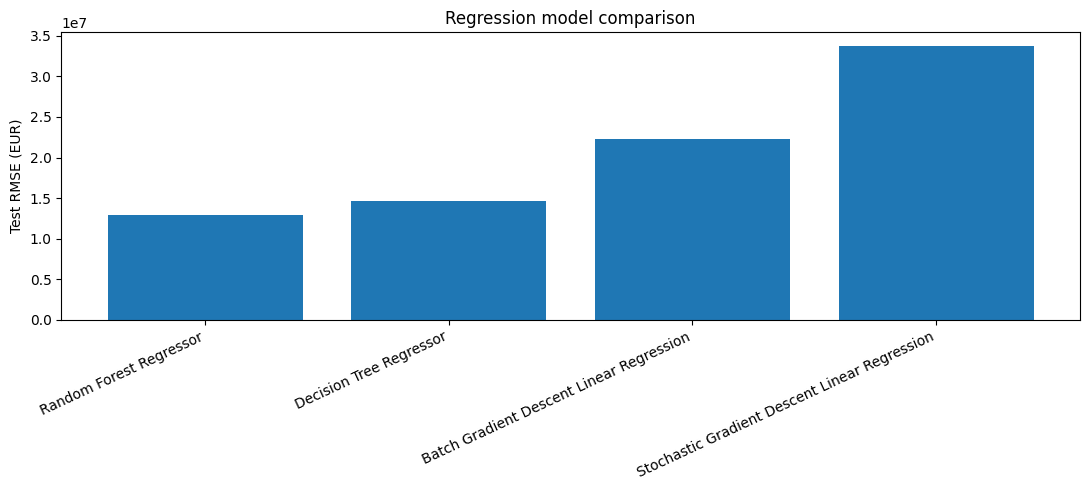

In [23]:
plt.figure(figsize=(11, 5))
plt.bar(results["model"], results["RMSE_EUR"])
plt.ylabel("Test RMSE (EUR)")
plt.title("Regression model comparison")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Metric interpretation**

- **MAE** is the average absolute euro error.
- **RMSE** gives more weight to large prediction errors.
- **R²** shows how much variation in market value is explained on unseen
  player-season groups.
- **MAPE** expresses the error as a percentage, but it can be affected by
  players with relatively small market values.

Negative R² for a model means it performed worse than predicting the test
mean. That result should be reported honestly rather than hidden.

## Step 11 — Plot training and testing loss curves

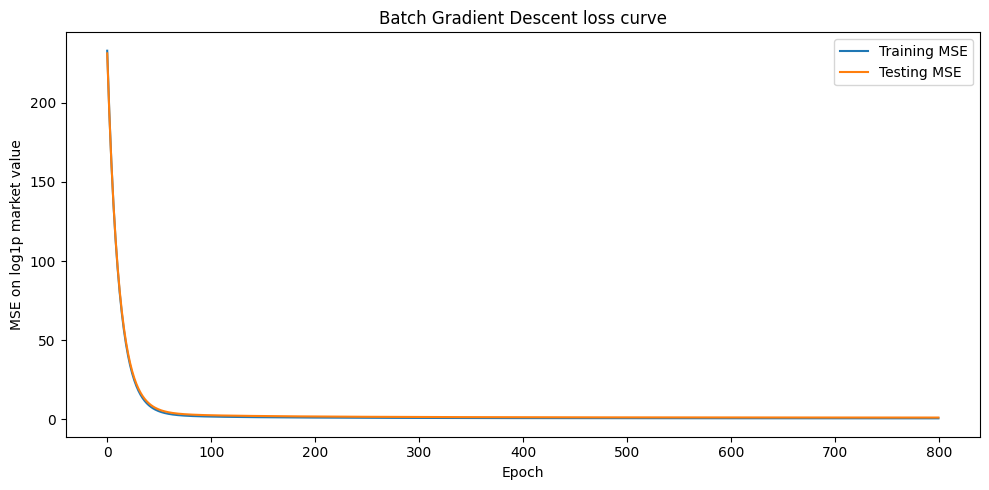

In [24]:
curve_preprocessor = clone(preprocessor)
X_train_curve = curve_preprocessor.fit_transform(X_train)
X_test_curve = curve_preprocessor.transform(X_test)

y_train_log = np.log1p(y_train.to_numpy())
y_test_log = np.log1p(y_test.to_numpy())

batch_curve_model = BatchGradientDescentRegressor(
    learning_rate=BEST_BATCH_RATE,
    max_epochs=800,
    l2_alpha=BEST_BATCH_ALPHA,
    n_iter_no_change=100,
)
batch_curve_model.fit_with_validation(
    X_train_curve,
    y_train_log,
    X_test_curve,
    y_test_log,
)

plt.figure(figsize=(10, 5))
plt.plot(
    batch_curve_model.train_loss_,
    label="Training MSE",
)
plt.plot(
    batch_curve_model.validation_loss_,
    label="Testing MSE",
)
plt.xlabel("Epoch")
plt.ylabel("MSE on log1p market value")
plt.title("Batch Gradient Descent loss curve")
plt.legend()
plt.tight_layout()
plt.show()

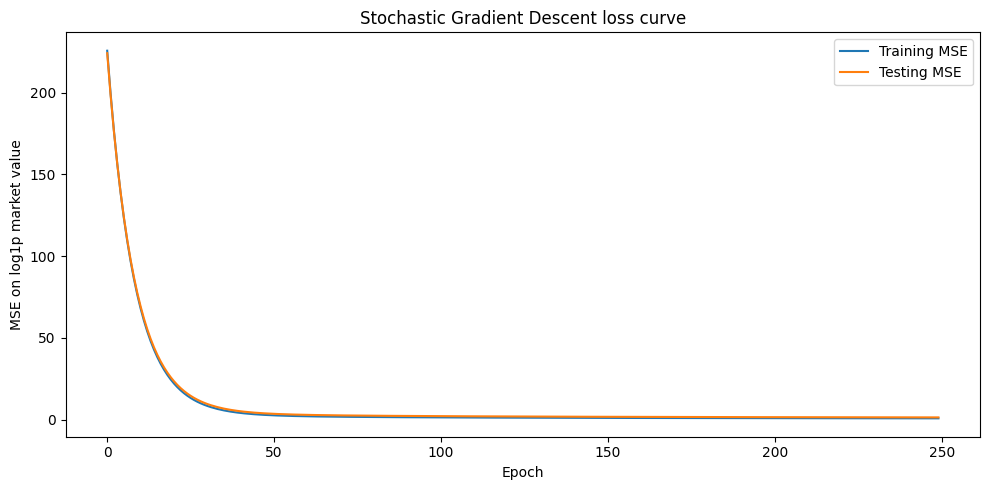

In [25]:
best_sgd_parameters = {
    key.split("__")[-1]: value
    for key, value in sgd_search.best_params_.items()
}

sgd_curve_model = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    learning_rate="constant",
    eta0=float(best_sgd_parameters["eta0"]),
    alpha=float(best_sgd_parameters["alpha"]),
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=RANDOM_STATE,
)

sgd_training_loss = []
sgd_testing_loss = []

for _ in range(250):
    sgd_curve_model.partial_fit(
        X_train_curve,
        y_train_log,
    )

    sgd_training_loss.append(
        mean_squared_error(
            y_train_log,
            sgd_curve_model.predict(X_train_curve),
        )
    )
    sgd_testing_loss.append(
        mean_squared_error(
            y_test_log,
            sgd_curve_model.predict(X_test_curve),
        )
    )

plt.figure(figsize=(10, 5))
plt.plot(
    sgd_training_loss,
    label="Training MSE",
)
plt.plot(
    sgd_testing_loss,
    label="Testing MSE",
)
plt.xlabel("Epoch")
plt.ylabel("MSE on log1p market value")
plt.title("Stochastic Gradient Descent loss curve")
plt.legend()
plt.tight_layout()
plt.show()

The test loss is plotted to satisfy the assignment requirement. It is
observed after each epoch but is not used in the gradient updates or
hyperparameter selection.

## Step 12 — Before-and-after scatter plots

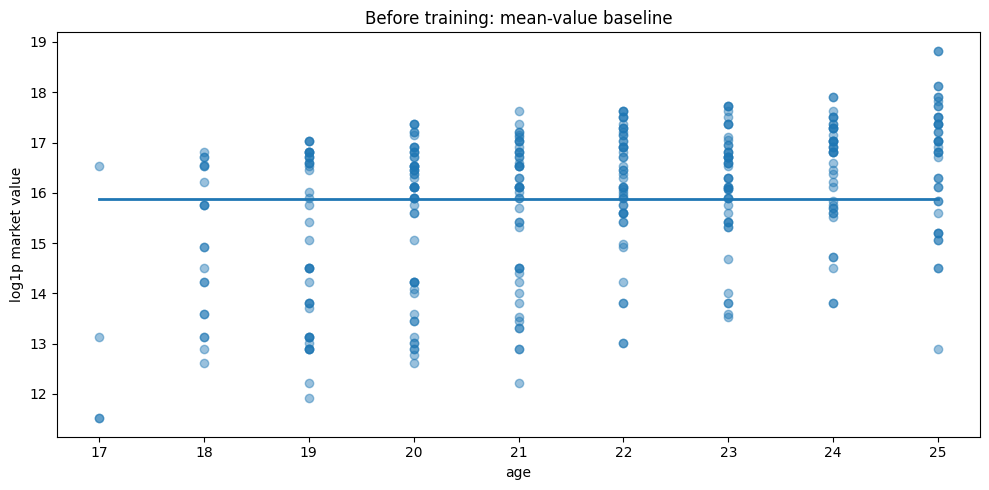

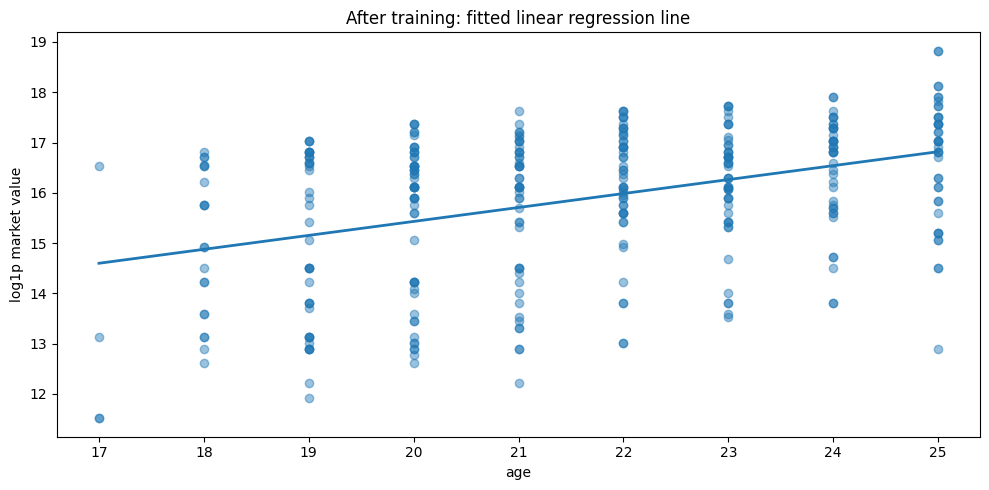

`age` was selected because it had the strongest absolute correlation with log market value among the chosen visualization variables. The final models use many variables, so this two-dimensional line is only an illustration.

In [26]:
scatter_candidates = [
    "age",
    "average_rating",
    "matches_played",
    "minutes_played",
    "goals",
    "assists",
    "total_shots",
]

scatter_correlations = (
    mission_df[scatter_candidates]
    .assign(
        log_market_value=np.log1p(
            mission_df["market_value_eur"]
        )
    )
    .corr(numeric_only=True)["log_market_value"]
    .drop("log_market_value")
    .sort_values(key=np.abs, ascending=False)
)

LINE_FEATURE = str(scatter_correlations.index[0])

line_data = mission_df[
    [LINE_FEATURE, "market_value_eur"]
].dropna().copy()
line_data["log_market_value"] = np.log1p(
    line_data["market_value_eur"]
)

X_line = line_data[[LINE_FEATURE]]
y_line = line_data["log_market_value"]

simple_line_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("linear_model", LinearRegression()),
    ]
)
simple_line_model.fit(X_line, y_line)

x_values = np.linspace(
    X_line[LINE_FEATURE].min(),
    X_line[LINE_FEATURE].max(),
    200,
)
x_frame = pd.DataFrame(
    {LINE_FEATURE: x_values}
)

plt.figure(figsize=(10, 5))
plt.scatter(
    X_line[LINE_FEATURE],
    y_line,
    alpha=0.45,
)
plt.plot(
    x_values,
    np.full_like(
        x_values,
        y_line.mean(),
        dtype=float,
    ),
    linewidth=2,
)
plt.xlabel(LINE_FEATURE)
plt.ylabel("log1p market value")
plt.title("Before training: mean-value baseline")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(
    X_line[LINE_FEATURE],
    y_line,
    alpha=0.45,
)
plt.plot(
    x_values,
    simple_line_model.predict(x_frame),
    linewidth=2,
)
plt.xlabel(LINE_FEATURE)
plt.ylabel("log1p market value")
plt.title("After training: fitted linear regression line")
plt.tight_layout()
plt.show()

display(
    Markdown(
        f"`{LINE_FEATURE}` was selected because it had the strongest "
        "absolute correlation with log market value among the chosen "
        "visualization variables. The final models use many variables, "
        "so this two-dimensional line is only an illustration."
    )
)

## Step 13 — Interpret which features hold more weight

In [27]:
fitted_pipeline = best_evaluation_model.regressor_
fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
fitted_regressor = fitted_pipeline.named_steps["model"]

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

if hasattr(fitted_regressor, "feature_importances_"):
    importance_values = fitted_regressor.feature_importances_
    importance_label = "feature_importance"
elif hasattr(fitted_regressor, "coef_"):
    importance_values = np.abs(
        np.ravel(fitted_regressor.coef_)
    )
    importance_label = "absolute_coefficient"
else:
    importance_values = np.array([])
    importance_label = "importance"

feature_importance = (
    pd.DataFrame(
        {
            "feature": transformed_feature_names,
            importance_label: importance_values,
        }
    )
    .sort_values(importance_label, ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(feature_importance)

display(
    Markdown(
        "**Interpretation:** These are the variables that most influenced "
        f"the selected `{BEST_MODEL_NAME}` model. For tree models, values "
        "are impurity-based feature importances. For linear models, they "
        "are absolute standardized coefficients. Importance does not prove "
        "that a feature causes market value."
    )
)

,feature,feature_importance
0,numeric__age,0.123
1,numeric__season_start_year,0.110
2,numeric__minutes_per_match,0.067
3,numeric__average_rating,0.052
4,numeric__pass_accuracy_percent,0.038
5,numeric__aerial_duels_won_per90,0.032
6,numeric__long_ball_accuracy_percent,0.032
7,categorical__league_Ligue 2,0.029
8,numeric__dribbled_past_per90,0.027
9,numeric__tackles_per90,0.027


**Interpretation:** These are the variables that most influenced the selected `Random Forest Regressor` model. For tree models, values are impurity-based feature importances. For linear models, they are absolute standardized coefficients. Importance does not prove that a feature causes market value.

## Step 14 — Predict one held-out data point

In [28]:
sample_index = X_test.index[0]
sample_raw_input = mission_df.loc[
    [sample_index],
    RAW_MODEL_COLUMNS,
].copy()
sample_model_input = prepare_model_features(
    sample_raw_input
)

sample_prediction = max(
    0.0,
    float(
        best_evaluation_model.predict(
            sample_model_input
        )[0]
    ),
)
sample_actual = float(
    mission_df.loc[
        sample_index,
        "market_value_eur",
    ]
)

prediction_example = pd.DataFrame(
    {
        "measurement": [
            "actual market value",
            "predicted market value",
            "absolute error",
        ],
        "EUR": [
            sample_actual,
            sample_prediction,
            abs(sample_actual - sample_prediction),
        ],
    }
)

display(sample_raw_input)
prediction_example

,age,nationality,position_code,season,league,competition_category,matches_played,minutes_played,goals,assists,average_rating,total_shots,shots_on_target,big_chances_missed,key_passes,big_chances_created,successful_dribbles,accurate_passes,pass_accuracy_percent,accurate_long_balls,long_ball_accuracy_percent,accurate_crosses,cross_accuracy_percent,clearances,yellow_cards,red_cards,errors_leading_to_goal,dribbled_past,tackles,interceptions,blocked_shots,aerial_duels_won
131,21,NGR,OS,17/18,Premier League,Domestic leagues,26,1843,3,5,7.100,45.000,23.000,2,38,6,36,985.000,86.600,28.000,59.600,3.000,15.000,1,1,0,0,13,19,7,11.000,3.000


,measurement,EUR
0,actual market value,"10,000,000.000"
1,predicted market value,"14,399,447.842"
2,absolute error,"4,399,447.842"


## Step 15 — Save the best model for Task 2

In [29]:
deployment_model = clone(best_evaluation_model)
deployment_model.fit(X, y)

MODEL_PATH = MODEL_DIR / "best_model.joblib"
METADATA_PATH = MODEL_DIR / "model_metadata.json"
SAMPLE_INPUT_PATH = MODEL_DIR / "sample_player_input.json"

joblib.dump(deployment_model, MODEL_PATH)

best_result = results.loc[
    results["model"] == BEST_MODEL_NAME
].iloc[0]

metadata = {
    "project": "Young African Football Market Value Prediction",
    "best_model_name": BEST_MODEL_NAME,
    "target": "market_value_eur",
    "age_range": [MINIMUM_AGE, MAXIMUM_AGE],
    "raw_input_columns": RAW_MODEL_COLUMNS,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "test_metrics": {
        "MAE_EUR": float(best_result["MAE_EUR"]),
        "RMSE_EUR": float(best_result["RMSE_EUR"]),
        "R2": float(best_result["R2"]),
        "MAPE_percent": float(
            best_result["MAPE_percent"]
        ),
    },
    "python_version": sys.version.split()[0],
    "scikit_learn_version": sklearn.__version__,
}

METADATA_PATH.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

def json_safe(value):
    if pd.isna(value):
        return None
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    return value

sample_payload = {
    column: json_safe(
        sample_raw_input.iloc[0][column]
    )
    for column in RAW_MODEL_COLUMNS
}

SAMPLE_INPUT_PATH.write_text(
    json.dumps(
        sample_payload,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

processed_output_path = (
    PROCESSED_DIR
    / "young_african_players_model_data.csv"
)
pd.concat(
    [
        mission_df[
            [
                "player",
                "player_season_group",
                "market_value_eur",
            ]
        ].reset_index(drop=True),
        model_features.reset_index(drop=True),
    ],
    axis=1,
).to_csv(
    processed_output_path,
    index=False,
)

saved_artifacts = pd.DataFrame(
    {
        "artifact": [
            "best deployment model",
            "model metadata",
            "sample API input",
            "processed modelling data",
        ],
        "path": [
            str(MODEL_PATH.relative_to(WORK_DIR)),
            str(METADATA_PATH.relative_to(WORK_DIR)),
            str(
                SAMPLE_INPUT_PATH.relative_to(
                    WORK_DIR
                )
            ),
            str(
                processed_output_path.relative_to(
                    WORK_DIR
                )
            ),
        ],
    }
)

saved_artifacts

,artifact,path
0,best deployment model,models/best_model.joblib
1,model metadata,models/model_metadata.json
2,sample API input,models/sample_player_input.json
3,processed modelling data,data/processed/young_african_players_model_dat...


## Step 16 — Package the Task 1 outputs

The following cell creates `task1_outputs.zip`. In Colab, open the **Files**
panel, open `african_football_task1`, right-click `task1_outputs.zip`, and
select **Download**.

In [30]:
OUTPUT_ZIP_PATH = WORK_DIR / "task1_outputs.zip"
with ZipFile(OUTPUT_ZIP_PATH, "w", ZIP_DEFLATED) as archive:
    for file_path in MODEL_DIR.glob("*"):
        if file_path.is_file():
            archive.write(file_path, file_path.name)

    processed_file = PROCESSED_DIR / "young_african_players_model_data.csv"
    if processed_file.exists():
        archive.write(processed_file, processed_file.name)

pd.DataFrame({"output_archive": [str(OUTPUT_ZIP_PATH)]})

,output_archive
0,/content/african_football_task1/task1_outputs.zip
